# Multi-Fidelity Bayesian Learning with SALSA

### Introduction to Multi-Fidelity Bayesian Learning : The Kennedy O'Hagan Framework

I modelli surrogati** (o emulatori) sono approssimazioni matematiche o computazionali utilizzate per replicare il comportamento di sistemi complessi e costosi, riducendo il costo delle valutazioni. Sono impiegati, tra gli altri, nel *design optimization*, nell'*Uncertainty Quantification* e nella *Bayesian Inference*. Nelle applicazioni reali emerge però un trade-off tra accuratezza e costo: i modelli High-Fidelity (HF) sono accurati ma costosi, mentre quelli Low-Fidelity (LF) sono economici ma meno precisi.

Il paradigma Multi-Fidelity (MF) combina fonti di informazione con diversi livelli di accuratezza e costo, sfruttando i dati LF per esplorare lo spazio dei parametri e ricorrendo a valutazioni HF mirate per correggere e calibrare il modello. In questo modo è possibile ottenere predizioni accurate riducendo il numero di costose valutazioni HF.

La fedeltà può essere intesa come il livello di accuratezza o complessità di una fonte, ma in senso più ampio una fonte LF può essere qualsiasi segnale correlato all'output di interesse, come dati storici, sensori rumorosi o simulazioni semplificate. I metodi MF sfruttano questa correlazione tra le diverse fonti per ricostruire la funzione target con un numero ridotto di valutazioni HF.

## Kennedy–O'Hagan framework (Co-kriging e AR1)

Il framework di Kennedy–O'Hagan (2000) costituisce la base teorica del Co-kriging multi-fidelity con Processi Gaussiani. Nel modello autoregressivo di primo ordine (AR1), la funzione High-Fidelity viene rappresentata come una versione linearmente scalata della Low-Fidelity, a cui si aggiunge una funzione di discrepanza:
$$
f_h(x) = \rho f_l(x) + f_\delta(x).
$$
Assumendo $f_l$ e $f_\delta$ come GP indipendenti, la combinazione rimane un Processo Gaussiano e permette di costruire una matrice di covarianza congiunta che descrive le dipendenze tra osservazioni LF e HF.

L'approccio AR1 è particolarmente efficace quando la LF riproduce bene la struttura globale della HF e la differenza tra le due può essere descritta da un semplice fattore di scala $\rho$ e da una discrepanza relativamente regolare. Tuttavia, l'ipotesi di una relazione lineare può risultare inadeguata quando il passaggio tra le fedeltà introduce distorsioni geometriche, risonanze o trasformazioni fortemente non lineari, limitando la capacità del modello di rappresentare correttamente la relazione LF–HF.

## Scelta dei punti Low-Fidelity e High-Fidelity

Poiché le valutazioni High-Fidelity sono computazionalmente costose, non è generalmente possibile campionare in modo denso l'intero spazio degli input. Una strategia consiste quindi nell'utilizzare il Latin Hypercube Sampling (LHS) per generare un design Low-Fidelity ben distribuito nello spazio: ogni dimensione viene suddivisa in intervalli equiprobabili e ciascun intervallo viene campionato una sola volta, garantendo una buona copertura dello spazio con un numero limitato di punti. A partire da questo insieme di valutazioni LF, i punti High-Fidelity non vengono invece scelti necessariamente a priori, ma possono essere selezionati adattivamente tramite un Processo Gaussiano (GP), sfruttandone la predizione e l'incertezza per individuare iterativamente le regioni dello spazio in cui una nuova valutazione HF risulta maggiormente informativa. La selezione adattiva dei punti HF tramite Active Learning sarà approfondita nel prossimo capitolo.

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent  # active/
sys.path.insert(0, str(project_root))

# from src.acquisition.alc import alcSampling
from src.acquisition.active_learning.alm import almSampling
from src.evaluation.surrogate_evaluator import SurrogateEvaluator
from src.initial_design.nested_lhs import NestedLHS
from src.problems.multifidelity.branin import Branin
from src.sampler.generators.multifidelity import MultiFidelityCandidateGenerator
from src.sampler.multifidelity import MultiFidelityExperiment
from src.surrogates.ResidualCoKriging import ResidualCoKriging
from src.visualization.active_learning_plots import ActiveLearningPlotter

### Multi-Fidelity Learning with Active learning MacKay on the branin function

MSE: 17.72825980566217
RMSE: 4.210494009693182
MAE: 2.364720212084363


c:\Users\tomma\OneDrive\Desktop\bayesiana\labs\SALSA\SALSA\src\visualization\active_learning_plots.py:109: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


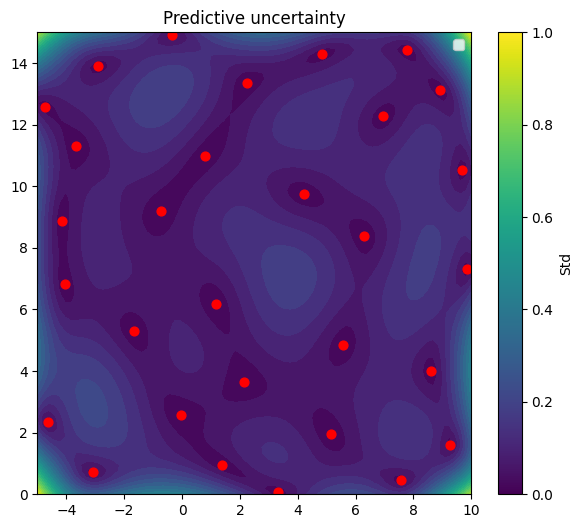

In [ ]:
problem = Branin()

design = NestedLHS(n_low=50, n_high=20)
dataset = design.generate(problem)

surrogate = ResidualCoKriging()

acquisition = almSampling()
candidate_generator = MultiFidelityCandidateGenerator()

evaluator = SurrogateEvaluator(
    problem,
    n_grid=80,
    seed=42
)

experiment = MultiFidelityExperiment(
    problem,
    dataset,
    surrogate,
    acquisition,
    candidate_generator,
    evaluator,
    budget=10
)


result = experiment.run()

surrogate_final = result["surrogate"] 
dataset_final = result["dataset"]
history = result["history"]

evaluation = evaluator.evaluate(surrogate_final)


print("MSE:",evaluation["mse"])
print("RMSE:",evaluation["rmse"])
print("MAE:",evaluation["mae"])

plotter = ActiveLearningPlotter(problem,evaluator)
plotter.plot_uncertainty(evaluation["X_test"], evaluation["std"], dataset_final.X_high)